In [2]:
import pandas as pd

TARGET_PATH1 = 'data/data1.csv'
TARGET_PATH2 = 'data/data2.csv'

df1 = pd.read_csv(TARGET_PATH1, encoding='utf-8-sig')
df2 = pd.read_csv(TARGET_PATH2, encoding='utf-8-sig')

# 두 파일을 위아래로 합치기
df = pd.concat([df1, df2], ignore_index=True)

print(df.head())

C:\Users\user\AppData\Local\Temp\ipykernel_12256\1704980144.py:6: DtypeWarning: Columns (30: 부선호출부호1) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv(TARGET_PATH1, encoding='utf-8-sig')


   항명    호출부호       선명  입항횟수  입항횟수.1  구분  외내  입출  총톤수              입항일시  ...  \
0  부산  796256      백경3  2004       1  최종  내항  출항   22  2004-01-01 00:00  ...   
1  부산  058251      대은호  2016       2  최종  내항  출항  124  2016-08-16 16:15  ...   
2  부산  915291    17금영호  2019       1  최종  내항  출항   22  2019-05-30 09:00  ...   
3  부산   JVNF8  SUNRISE  2019       1  최종  외항  출항   19  2019-11-21 18:00  ...   
4  부산  030713      청운호  2021       1  최초  내항  출항  121  2021-01-01 00:00  ...   

  외항:외국인선원수\r\n내항:보통선원수 승무원승선수 승무원하선수 승객승선수 승객하선수   승객 예선 도선 부선호출부호1 부선호출부호2  
0                   0.0    0.0    0.0   0.0   0.0  0.0  N  N     NaN     NaN  
1                   1.0    0.0    0.0   0.0   0.0  0.0  N  N     NaN     NaN  
2                   0.0    0.0    0.0   0.0   0.0  0.0  N  N     NaN     NaN  
3                   1.0    NaN    NaN   NaN   NaN  2.0  N  N     NaN     NaN  
4                   1.0    0.0    0.0   0.0   0.0  0.0  N  N     NaN     NaN  

[5 rows x 32 columns]


C:\Users\user\AppData\Local\Temp\ipykernel_12256\1704980144.py:7: DtypeWarning: Columns (30: 부선호출부호1) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv(TARGET_PATH2, encoding='utf-8-sig')


In [13]:
df.columns = df.columns.str.strip()

In [15]:
print(df.columns.tolist())

['선명', '입항횟수', '입항횟수.1', '구분', '외내', '입출', '총톤수', '입항일시', '출항일시', '항해구분', '계선장소.1', '계선장소.2', '차항지', '전출항지', '선박용도', '외항:한국인선원수\r\n내항:해기사선원수', '외항:외국인선원수\r\n내항:보통선원수']


In [17]:
df=df.drop(columns=['선명','입항횟수', '입항횟수.1','계선장소.1','계선장소.2','외항:한국인선원수\r\n내항:해기사선원수', '외항:외국인선원수\r\n내항:보통선원수'])


In [18]:
filtered_df = df[df['외내'] == '외항']



In [19]:
filtered_df.head()

,구분,외내,입출,총톤수,입항일시,출항일시,항해구분,차항지,전출항지,선박용도
3,최종,외항,출항,19,2019-11-21 18:00,2024-05-10 11:30,기타,속초,HAKATA/FUKUOKA,수상레저기구
13,최종,외항,출항,703,2022-07-23 10:35,2024-03-14 18:00,기타,감천,SHIMONOSEKI,냉동.냉장선
15,최종,외항,출항,98,2022-09-22 09:15,2024-03-18 18:00,기타,VLADIVOSTOK,부산,냉동.냉장선
16,최종,외항,출항,319,2022-09-22 14:00,2024-06-08 08:00,기타,부산,부산,원양 어선
17,최종,외항,출항,759,2022-09-22 16:00,2024-07-30 13:00,기타,목포,부산,원양 어선


In [20]:
# 전출항지 별로 그룹 묶기
print(filtered_df['전출항지'].drop_duplicates().to_string(index=False))

                 HAKATA/FUKUOKA
                    SHIMONOSEKI
                             부산
                 OCEAN DISTRICT
                         HIMEJI
                       NAKHODKA
                    VLADIVOSTOK
                      HACHINOHE
                        OKHOTSK
                             울산
                      HONG KONG
                        NEVELSK
                      SLAVYANKA
                         MAJURO
                             목포
                             고현
                       ZARUBINO
                         DALIAN
                            기타항
                 SEVERO-KURILSK
                MOJI/KITAKYUSHU
                             감천
           WAKAMATSU/KITAKYUSHU
                        SHIMIZU
                         FUZHOU
                     LONGYAN PT
                  IKI, NAGASAKI
                        KHOLMSK
                      WEIHAI PT
              BATAAN, MARIVELES
                        KUSHIRO
      PE

In [21]:
filtered_df['전출항지'].value_counts().head(10)

전출항지
QINGDAO           2642
SHANGHAI          2441
VLADIVOSTOK       2155
광양                1942
HAKATA/FUKUOKA    1904
HITAKATSU         1470
NINGBO            1233
울산                1154
인천                1099
KOBE              1004
Name: count, dtype: int64

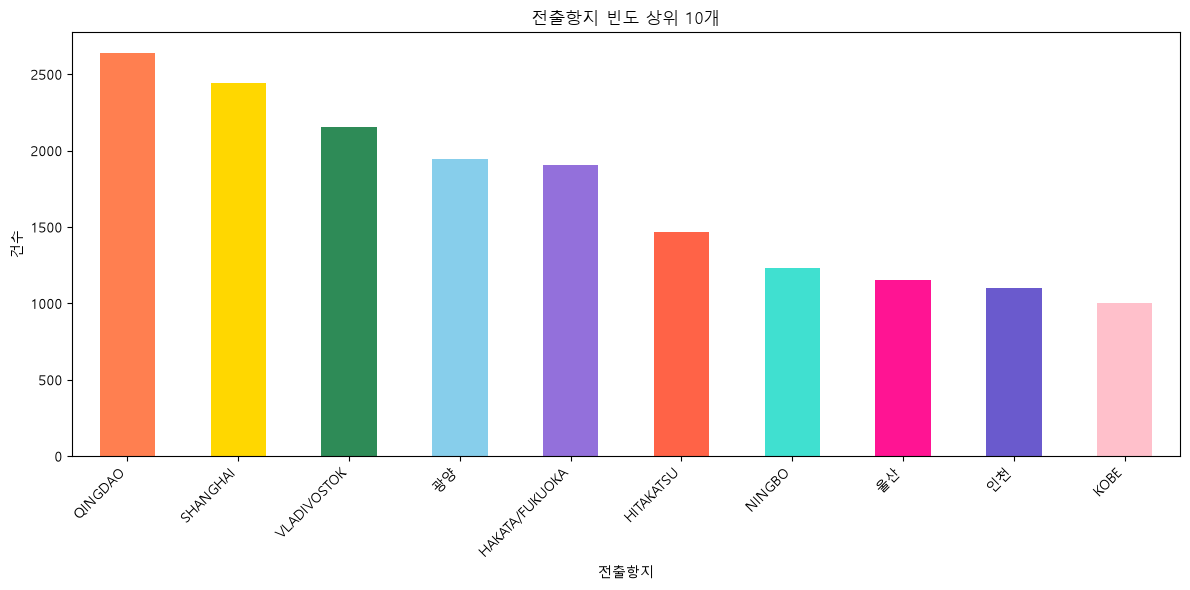

In [29]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 표시

top10 = filtered_df['전출항지'].value_counts().head(10)

plt.figure(figsize=(12, 6))
colors = ['coral', 'gold', 'seagreen', 'skyblue', 'mediumpurple',
          'tomato', 'turquoise', 'deeppink', 'slateblue', 'pink']
top10.plot(kind='bar', color=colors)
plt.title('전출항지 빈도 상위 10개')
plt.xlabel('전출항지')
plt.ylabel('건수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [27]:
top10_ports = filtered_df['전출항지'].value_counts().head(10).index

time_df = filtered_df[filtered_df['전출항지'].isin(top10_ports)].copy()
time_df['입항일시'] = pd.to_datetime(time_df['입항일시'], errors='coerce')
time_df['출항일시'] = pd.to_datetime(time_df['출항일시'], errors='coerce')
time_df['체류시간_시간'] = (
    time_df['출항일시'] - time_df['입항일시']
).dt.total_seconds() / 3600

valid_time_df = time_df[
    time_df['체류시간_시간'].between(0, 48)
]

avg_hours = (
    valid_time_df.groupby('전출항지')['체류시간_시간']
    .mean()
    .reindex(top10_ports)
    .round(2)
)

print(avg_hours)

전출항지
QINGDAO           23.53
SHANGHAI          23.43
VLADIVOSTOK       17.97
광양                20.74
HAKATA/FUKUOKA    12.32
HITAKATSU         13.17
NINGBO            24.63
울산                22.05
인천                16.93
KOBE              17.51
Name: 체류시간_시간, dtype: float64


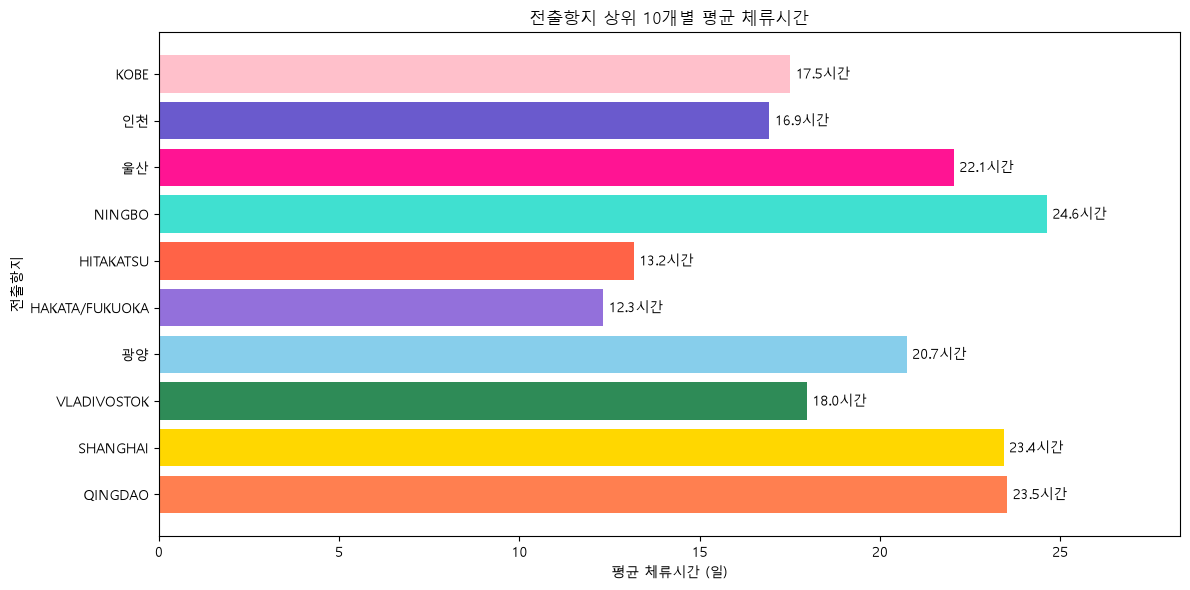

In [30]:
avg_days = avg_hours.dropna().sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['coral', 'gold', 'seagreen', 'skyblue', 'mediumpurple',
          'tomato', 'turquoise', 'deeppink', 'slateblue', 'pink']
bars = ax.barh(avg_hours.index, avg_hours.values, color=colors)

ax.bar_label(bars, fmt='%.1f시간', padding=4)
ax.set_title('전출항지 상위 10개별 평균 체류시간')
ax.set_xlabel('평균 체류시간 (일)')
ax.set_ylabel('전출항지')
ax.set_xlim(right=avg_days.max() * 1.15)  # 숫자 표시 공간
plt.tight_layout()
plt.show()

## 닝보가 1위, 칭다오가 2위, 상하이가 3위로 입항해서 출항하기까지 소요시간이 오래 걸린다.
###  아시아 주요 항만의 적체에 영향을 받아 부산의 정시성은 40.9%까지 떨어졌다.(26.09_Sea Intelligence 통계)
### 중국에서 온 배가 들어와 환적항으로서의 기능 위주로 수행하고 있기 때문에 해당 정체 상황에 대한 대응이 필요해보인다.

### 다만 전 항구인 닝보,칭다오,상하이의 지연이 영향을 끼쳤다고 확신할 순 없다. 대형선박인지 화물총톤수가 높은지에 따라 평균소요시간에 영향을 끼칠 수 있다.



In [32]:
filtered_df['차항지'].value_counts().head(10)
# ocean district : 선박의 입출항 신고서 등에서 특정 목적지가 없는 공해상(Ocean District)을 의미하는 약어(OC)로 사용되기도 합니다.

차항지
광양                3375
SHANGHAI          2511
OCEAN DISTRICT    2407
VLADIVOSTOK       2270
울산                2153
HITAKATSU         1553
HAKATA/FUKUOKA    1551
QINGDAO           1522
SHIMONOSEKI       1109
TOKYO              875
Name: count, dtype: int64

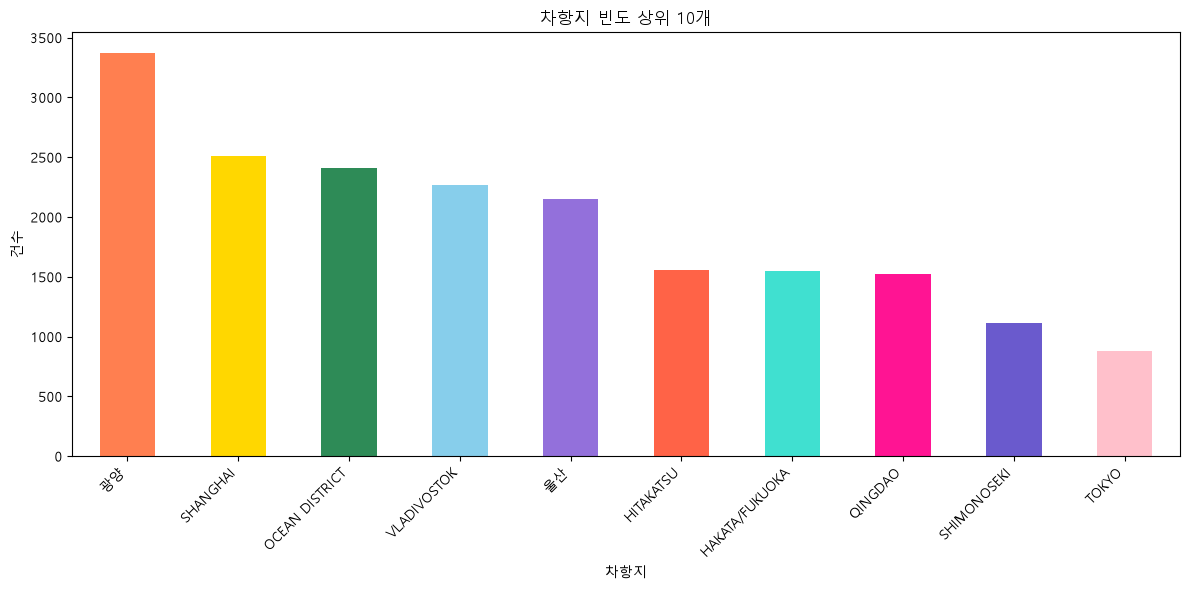

In [33]:
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 표시

top10 = filtered_df['차항지'].value_counts().head(10)

plt.figure(figsize=(12, 6))
colors = ['coral', 'gold', 'seagreen', 'skyblue', 'mediumpurple',
          'tomato', 'turquoise', 'deeppink', 'slateblue', 'pink']
top10.plot(kind='bar', color=colors)
plt.title('차항지 빈도 상위 10개')
plt.xlabel('차항지')
plt.ylabel('건수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [34]:
top10_ports = filtered_df['전출항지'].value_counts().head(10).index

tonnage_df = filtered_df[
    filtered_df['전출항지'].isin(top10_ports)
].copy()

tonnage_df['총톤수'] = pd.to_numeric(
    tonnage_df['총톤수'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

tonnage_sum = (
    tonnage_df.groupby('전출항지')['총톤수']
    .sum()
    .reindex(top10_ports)
)

print(tonnage_sum)

전출항지
QINGDAO           188638432
SHANGHAI          144745690
VLADIVOSTOK        18783512
광양                 52599706
HAKATA/FUKUOKA     27024007
HITAKATSU            777073
NINGBO             93088717
울산                 15803608
인천                 18845510
KOBE               17820431
Name: 총톤수, dtype: int64


In [35]:
total_tonnage = tonnage_sum.sum()

tonnage_ratio = pd.DataFrame({
    '총톤수 합계': tonnage_sum,
    '비율(%)': (tonnage_sum / total_tonnage * 100).round(2)
})

print(f'상위 10개 총톤수 합계: {total_tonnage:,.0f}')
display(tonnage_ratio)


상위 10개 총톤수 합계: 578,126,686


,총톤수 합계,비율(%)
전출항지,,
QINGDAO,188638432,32.63
SHANGHAI,144745690,25.04
VLADIVOSTOK,18783512,3.25
광양,52599706,9.10
HAKATA/FUKUOKA,27024007,4.67
HITAKATSU,777073,0.13
NINGBO,93088717,16.10
울산,15803608,2.73
인천,18845510,3.26


### 화물 비중이 높은 항로일수록 체류시간이 증가하는가?

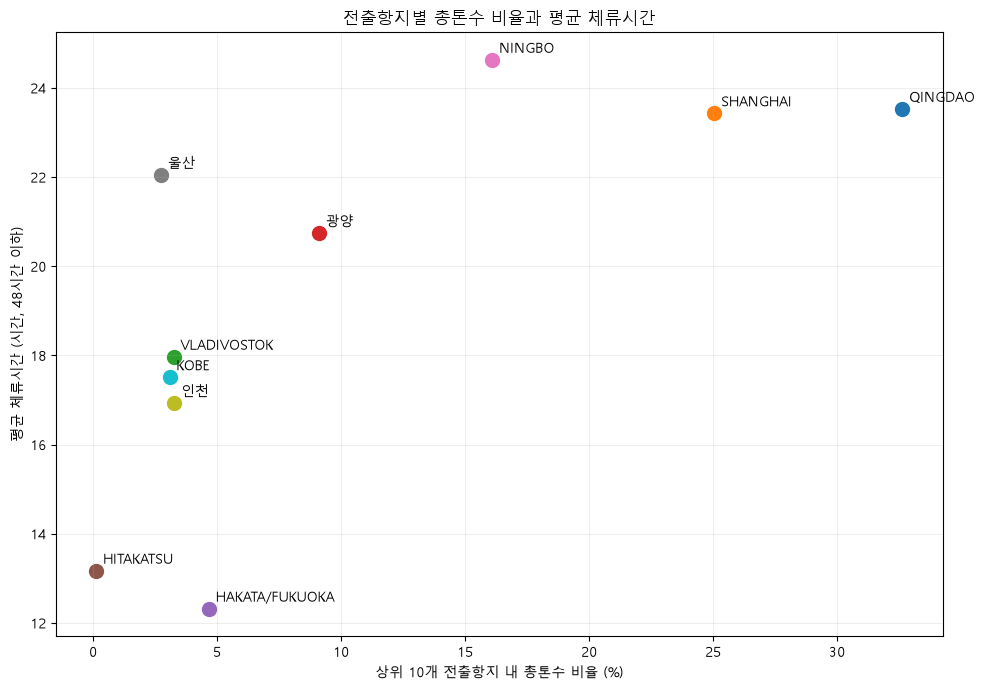

In [37]:
plot_df = pd.concat(
    [
        tonnage_ratio['비율(%)'],
        avg_hours.rename('평균 체류시간(시간)')
    ],
    axis=1
).dropna()

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.get_cmap('tab10').colors

for i, (port, row) in enumerate(plot_df.iterrows()):
    ax.scatter(
        row['비율(%)'],
        row['평균 체류시간(시간)'],
        color=colors[i % 10],
        s=100
    )
    ax.annotate(
        port,
        (row['비율(%)'], row['평균 체류시간(시간)']),
        xytext=(5, 5),
        textcoords='offset points'
    )

ax.set_xlabel('상위 10개 전출항지 내 총톤수 비율 (%)')
ax.set_ylabel('평균 체류시간 (시간, 48시간 이하)')
ax.set_title('전출항지별 총톤수 비율과 평균 체류시간')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()